In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [16]:
df = pd.read_csv("E:/study/Data Sci/Road traffic noise/urban_noise_levels.csv")

In [17]:
df.head()

,id,latitude,longitude,datetime,decibel_level,hour,day_of_week,is_weekend,temperature_c,humidity_%,...,population_density,park_proximity,industrial_zone,vehicle_count,honking_events,public_event,holiday,school_zone,noise_complaints,sensor_id
0,1,40.649816,-74.069147,2023-04-01 18:50:00,78.286408,18,5,1,16.710979,43.054747,...,28384,0,0,24,1,0,0,1,1,31
1,2,40.880286,-74.076511,2023-03-18 04:12:00,68.131845,4,5,1,10.088749,29.676246,...,24206,0,0,15,2,0,0,0,0,40
2,3,40.792798,-73.746873,2023-12-03 05:43:00,58.934966,5,6,1,19.911075,47.932832,...,1894,1,0,15,2,0,0,0,0,41
3,4,40.739463,-74.075227,2023-06-20 00:44:00,69.559042,0,1,0,3.477520,88.594010,...,2265,1,0,24,4,0,0,1,2,50
4,5,40.562407,-74.064025,2023-12-28 12:06:00,60.409097,12,3,0,17.356303,35.811699,...,23807,1,0,25,2,0,0,0,0,8


In [18]:
len(df['latitude'].unique()) == len(df)

True

In [19]:
hr = df['hour'].unique()
len(hr) #This tells us that all 24 hours are there 

24

As there are 24 hours so we have problems:
1) The lenth of unique latitude is same as the number of data points, so we do not have different time stamps for each location
2) Rather we have different latitudes for same time stamps 

---
The column 'id' shall be droped as not needed

---
As we have 'hour' so time column is not needed and date is also not needed as we have day of week

---
Decible level shall be the output

In [20]:
sns = df['hour'].unique()
len(sns) 

24

In [21]:
df.describe()

,id,latitude,longitude,decibel_level,hour,day_of_week,is_weekend,temperature_c,humidity_%,wind_speed_kmh,...,population_density,park_proximity,industrial_zone,vehicle_count,honking_events,public_event,holiday,school_zone,noise_complaints,sensor_id
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,40.699455,-73.951805,64.815110,11.606500,3.060000,0.295500,17.696283,55.179931,20.104265,...,15559.801500,0.497500,0.144000,20.109000,2.98500,0.056500,0.106000,0.144000,0.986000,25.541500
std,577.494589,0.116884,0.144290,10.069717,6.994149,1.966554,0.456381,7.165606,19.992284,11.679273,...,8369.974373,0.500119,0.351178,4.499694,1.71004,0.230942,0.307915,0.351178,0.984016,14.410555
min,1.000000,40.501287,-74.199994,33.232962,0.000000,0.000000,0.000000,-4.547114,20.003698,0.006310,...,1018.000000,0.000000,0.000000,7.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,40.595219,-74.074607,57.907870,6.000000,1.000000,0.000000,12.775756,37.986261,10.025685,...,8490.500000,0.000000,0.000000,17.000000,2.00000,0.000000,0.000000,0.000000,0.000000,14.000000
50%,1000.500000,40.702941,-73.953653,65.019535,12.000000,3.000000,0.000000,17.635835,55.204723,19.819367,...,15668.500000,0.000000,0.000000,20.000000,3.00000,0.000000,0.000000,0.000000,1.000000,26.000000
75%,1500.250000,40.800272,-73.825655,71.647588,18.000000,5.000000,1.000000,22.756373,72.396867,30.468300,...,22798.000000,1.000000,0.000000,23.000000,4.00000,0.000000,0.000000,0.000000,2.000000,38.000000
max,2000.000000,40.899887,-73.700221,97.430930,23.000000,6.000000,1.000000,40.000000,89.977124,39.973405,...,29991.000000,1.000000,1.000000,39.000000,10.00000,1.000000,1.000000,1.000000,5.000000,50.000000


### We must filter unwanted data points

In [22]:
loc = df.drop(
    df[
        (df["latitude"] <= 40.5838312) &
        (df["longitude"] >= -73.8022403)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5411031) &
        (loc["longitude"] >= -74.1277378)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5326989) &
        (loc["longitude"] >= -74.1536781)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5253637) &
        (loc["longitude"] >= -74.1916421)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5542136) &
        (loc["longitude"] >= -73.9077879)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5666088) &
        (loc["longitude"] >= -73.8663559)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5758487) &
        (loc["longitude"] >= -73.8469816)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] <= 40.5517675) &
        (loc["longitude"] >= -73.9211195)
    ].index
)

In [23]:
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.5324879) &
        (loc["latitude"] <= 40.5733421) &
        (loc["longitude"] >= -74.0819914) &
        (loc["longitude"] <= -73.9426003)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.5324879) &
        (loc["latitude"] <= 40.5632524) &
        (loc["longitude"] >= -74.0993335) &
        (loc["longitude"] <= -73.9426003)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.5547901) &
        (loc["latitude"] <= 40.6009929) & #upper left
        (loc["longitude"] >= -74.0655535) & #upper left
        (loc["longitude"] <= -74.0146274)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.6116312) &
        (loc["latitude"] <= 40.6906716) & #upper left
        (loc["longitude"] >= -74.0543247) & #upper left
        (loc["longitude"] <= -74.0342471)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.6133006) &
        (loc["latitude"] <= 40.6934247) & #upper left
        (loc["longitude"] >= -74.0699543) & #upper left
        (loc["longitude"] <= -74.0446446)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.6553590) &
        (loc["latitude"] <= 40.7163810) & #upper left
        (loc["longitude"] >= -74.0324849) & #upper left
        (loc["longitude"] <= -74.0063518)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.6910333) &
        (loc["latitude"] <= 40.7627989) & #upper left
        (loc["longitude"] >= -74.0235806) & #upper left
        (loc["longitude"] <= -74.0342471)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.7050121) &
        (loc["latitude"] <= 40.7625793) & #upper left
        (loc["longitude"] >= -74.0230287) & #upper left
        (loc["longitude"] <= -74.0165854)
    ].index
)

In [24]:
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.7263021) &
        (loc["latitude"] <= 40.7707340) & #upper left
        (loc["longitude"] >= -74.0168409) & #upper left
        (loc["longitude"] <= -74.0098242)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.8189764) &
        (loc["latitude"] <= 40.8276430) & #upper left
        (loc["longitude"] >= -73.9712088) & #upper left
        (loc["longitude"] <= -73.9619622)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.8474055) &
        (loc["latitude"] <= 40.9080247) & #upper left
        (loc["longitude"] >= -73.9442526) & #upper left
        (loc["longitude"] <= -73.9312442)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.5926963) &
        (loc["latitude"] <= 40.6321010) & #upper left
        (loc["longitude"] >= -73.8819586) & #upper left
        (loc["longitude"] <= -73.8095326)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.5874122) &
        (loc["latitude"] <= 40.5959257) & #upper left
        (loc["longitude"] >= -73.8708274) & #upper left
        (loc["longitude"] <= -73.8192415)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.6014590) &
        (loc["latitude"] <= 40.6243014) & #upper left
        (loc["longitude"] >= -73.8063904) & #upper left
        (loc["longitude"] <= -73.7681820)
    ].index
)
loc = loc.drop(
    loc[
        (loc["latitude"] >= 40.8709663) &
        (loc["latitude"] <= 40.8996937) & #upper left
        (loc["longitude"] >= -73.7789718) & #upper left
        (loc["longitude"] <= -73.6770355)
    ].index
)

---
Only run the next code for visual reprsentation of datapoints on a map

In [ ]:
#import folium

# Center of New York
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add points
for _, row in loc.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color='red',
        fill=True,
        fill_color='red'
    ).add_to(nyc_map)

# Save map
nyc_map.save("nyc19_map.html")

---

In [25]:
len(loc)

1518

In [30]:
loc = loc.drop(['id','latitude','longitude','datetime'], axis = 1)

In [31]:
X = loc.drop(['decibel_level'],axis = 1)

In [32]:
Y = loc['decibel_level']

In [33]:
X.head()

,hour,day_of_week,is_weekend,temperature_c,humidity_%,wind_speed_kmh,precipitation_mm,traffic_density,near_airport,near_highway,...,population_density,park_proximity,industrial_zone,vehicle_count,honking_events,public_event,holiday,school_zone,noise_complaints,sensor_id
1,4,5,1,10.088749,29.676246,15.681181,0.008220,2,0,0,...,24206,0,0,15,2,0,0,0,0,40
2,5,6,1,19.911075,47.932832,36.197181,0.839945,4,0,1,...,1894,1,0,15,2,0,0,0,0,41
3,0,1,0,3.477520,88.594010,22.400160,6.938482,4,0,0,...,2265,1,0,24,4,0,0,1,2,50
7,18,3,0,24.815356,24.971720,31.782092,0.880392,3,0,1,...,10965,1,0,26,3,0,0,1,1,47
8,3,4,0,14.475013,54.151362,1.600525,0.372272,2,0,0,...,9505,1,1,27,4,0,1,0,1,31


In [43]:
len(Y.unique())

1518

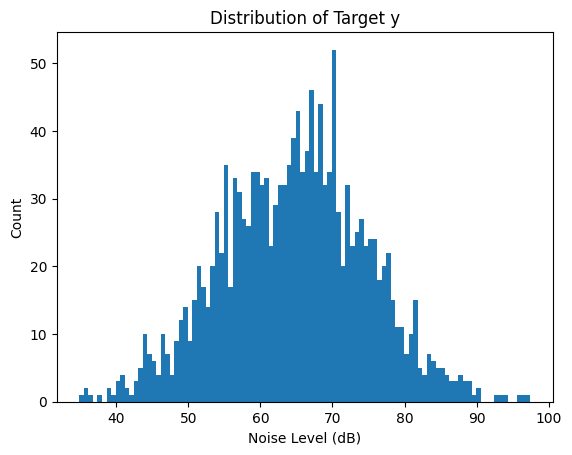

In [46]:
plt.hist(Y, bins=100)

plt.xlabel("Noise Level (dB)")
plt.ylabel("Count")
plt.title("Distribution of Target y")
plt.show()

In [63]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size = 0.2)

In [64]:
x_train = pd.get_dummies(x_train, columns=['sensor_id'])
x_test  = pd.get_dummies(x_test, columns=['sensor_id'])

In [65]:
x_train, x_test = x_train.align(
    x_test,
    join='left',
    axis=1,
    fill_value=0
)

In [66]:
x_train.head()

,hour,day_of_week,is_weekend,temperature_c,humidity_%,wind_speed_kmh,precipitation_mm,traffic_density,near_airport,near_highway,...,sensor_id_41,sensor_id_42,sensor_id_43,sensor_id_44,sensor_id_45,sensor_id_46,sensor_id_47,sensor_id_48,sensor_id_49,sensor_id_50
396,11,4,0,17.554985,27.856875,24.136703,2.372737,3,0,0,...,False,False,False,False,False,False,False,False,False,False
294,3,5,1,29.932145,81.341978,9.112030,2.012722,1,0,0,...,False,False,False,False,False,False,False,False,False,False
195,12,6,1,26.135817,25.585239,30.453986,3.848510,4,0,0,...,False,False,False,False,False,False,False,False,False,False
1146,22,6,1,4.368603,55.881365,24.597367,0.214183,2,0,1,...,False,False,False,False,False,False,False,False,False,False
1539,23,4,0,25.891451,83.194323,8.068182,4.391695,3,0,1,...,False,False,False,False,False,False,False,False,False,False


---
When One Hot Encoding for any model, theoretically we write the particular column as [0,0,...,0,1,0,0,..].
But, in practice hat happens is that if we have 5 unique values in the feature it creates 5 different columns each for 0,1 written as false or true.